In [ ]:
#setup
!gsutil ls gs://nutrition5k_dataset/nutrition5k_dataset/
!gsutil ls gs://nutrition5k_dataset/nutrition5k_dataset/imagery/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://nutrition5k_dataset/nutrition5k_dataset/README
gs://nutrition5k_dataset/nutrition5k_dataset/dish_ids/
gs://nutrition5k_dataset/nutrition5k_dataset/imagery/
gs://nutrition5k_dataset/nutrition5k_dataset/metadata/
gs://nutrition5k_dataset/nutrition5k_dataset/scripts/
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/
gs://nutrition5k_dataset/nutrition5k_dataset/imagery/side_angles/


In [ ]:
!mkdir -p /content/n5k/metadata /content/n5k/splits
!gsutil -m cp gs://nutrition5k_dataset/nutrition5k_dataset/metadata/*.csv /content/n5k/metadata/
!gsutil -m cp -r gs://nutrition5k_dataset/nutrition5k_dataset/dish_ids/ /content/n5k/splits/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://nutrition5k_dataset/nutrition5k_dataset/metadata/dish_metadata_cafe2.csv...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/metadata/dish_metadata_cafe1.csv...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/metadata/ingredients_metadata.csv...
/ [3/3 files][  2.2 MiB/  2.2 MiB] 100% Done                                    
Operation completed over 3 objects/2.2 MiB.                                      
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://nutrition5k_dataset/nutrition5k_datase

In [ ]:
!mkdir -p /content/n5k/imagery
!gsutil -m cp -r gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/ /content/n5k/imagery/

Streaming output truncated to the last 5000 lines.
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1562876732/depth_color.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1562876732/depth_raw.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1562876732/rgb.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1562876756/depth_color.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1562876756/depth_raw.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1562876756/rgb.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1562945131/depth_color.png...
Copying gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1562945131/depth_raw.png...
Copying gs://nutrition5k_dataset/nutrition5k_datase

In [ ]:
#UNZIP
from google.colab import drive
drive.mount('/content/drive')
!unzip -q /content/drive/MyDrive/aps360_project/n5k_overhead.zip -d /content/

Mounted at /content/drive


In [ ]:
#one time download
!mkdir -p /content/drive/MyDrive/aps360_project
!cp /content/n5k_overhead.zip /content/drive/MyDrive/aps360_project/
!cd /content && zip -rq n5k_overhead.zip n5k/
!cp /content/n5k_overhead.zip /content/drive/MyDrive/aps360_project/

dataset link: https://drive.google.com/drive/folders/1lwN_leL7HUSj5yU6LzmC3HAtTr34kWPK?usp=drive_link

note that raw data is a zip because the actual file is too big for my drive

## Data Processing

In [ ]:
import pandas as pd
import numpy as np
import os

In [ ]:
def parse_metadata(path):
    rows = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 6:
                continue
            try:
                rows.append({
                    'dish_id': parts[0],
                    'calories': float(parts[1]),
                    'mass': float(parts[2]),
                    'fat': float(parts[3]),
                    'carbs': float(parts[4]),
                    'protein': float(parts[5]),
                })
            except ValueError:
                continue  # corrupted row
    return pd.DataFrame(rows)

meta = pd.concat([
    parse_metadata('/content/n5k/metadata/dish_metadata_cafe1.csv'),
    parse_metadata('/content/n5k/metadata/dish_metadata_cafe2.csv'),
], ignore_index=True).drop_duplicates(subset='dish_id')

print("parsed dishes: ", len(meta))

parsed dishes:  5006


In [ ]:
#only keep ones with RGB images
IMG_ROOT = '/content/n5k/imagery/realsense_overhead'

def has_rgb(dish_id):
    return os.path.isfile(os.path.join(IMG_ROOT, dish_id, 'rgb.png'))

meta = meta[meta['dish_id'].apply(has_rgb)].reset_index(drop=True)
print(f"dishes with overhead rgb: {len(meta)}")

dishes with overhead rgb: 3490


In [ ]:
#cap outliers
targets = ['calories','mass','protein','carbs','fat']
cal_cap = meta['calories'].quantile(0.99)
mass_cap = meta['mass'].quantile(0.99)

before = len(meta)
meta = meta[
    (meta['calories'] <= cal_cap) &
    (meta['mass'] <= mass_cap) &
    (meta['mass'] > 0)
].reset_index(drop=True)
print("caps: calories: ", cal_cap , "mass: ", mass_cap)
print("dropped: ", before - len(meta), " ", len(meta), "remain")

caps: calories:  908.7176857800001 mass:  696.1100000000001
dropped:  63   3427 remain


In [ ]:
!ls /content/n5k/splits/dish_ids/splits/

depth_test_ids.txt  depth_train_ids.txt  rgb_test_ids.txt  rgb_train_ids.txt


In [ ]:
def load_split(path):
    with open(path) as f:
        return set(line.strip() for line in f if line.strip())
train_ids = load_split('/content/n5k/splits/dish_ids/splits/rgb_train_ids.txt')
test_ids  = load_split('/content/n5k/splits/dish_ids/splits/rgb_test_ids.txt')

train_df = meta[meta['dish_id'].isin(train_ids)].reset_index(drop=True)
test_df  = meta[meta['dish_id'].isin(test_ids)].reset_index(drop=True)
rng = np.random.RandomState(42)
val_mask = rng.rand(len(train_df)) < 0.15
val_df   = train_df[val_mask].reset_index(drop=True)
train_df = train_df[~val_mask].reset_index(drop=True)
print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")


train: 2265  val: 438  test: 496


In [ ]:
#stats + save for future use
stats = train_df[targets].agg(['mean', 'std', 'min', 'max']).T
print(stats)

target_mean = stats['mean'].to_numpy()
target_std  = stats['std'].to_numpy()

np.save('/content/n5k/target_mean.npy', target_mean)
np.save('/content/n5k/target_std.npy', target_std)

stats.round(2).to_csv('/content/n5k/target_stats.csv')


                mean         std  min         max
calories  244.680123  192.997100  0.0  908.604980
mass      209.672406  139.322155  5.0  662.000000
protein    17.344530   19.082290  0.0  133.227585
carbs      18.469285   14.993996  0.0   79.158340
fat        12.335556   12.377469  0.0   66.768997


In [ ]:
#dataset and dataloaders
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class Nutrition5kDataset(Dataset):
  def __init__(self, df, img_root, mean, std, train=False):
        self.df = df
        self.img_root = img_root
        self.mean = torch.tensor(mean)
        self.std = torch.tensor(std)
        base = [
            transforms.Resize(256),
            transforms.CenterCrop(224),
        ]
        aug = [
            transforms.Resize(256),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        ]
        self.tf = transforms.Compose(
            (aug if train else base) + [
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225]),])
  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    img = Image.open(os.path.join(self.img_root, row['dish_id'], 'rgb.png')).convert('RGB')
    img = self.tf(img)
    y = torch.tensor(row[targets].values.astype(np.float32))
    y = (y - self.mean) / self.std
    return img, y

train_ds = Nutrition5kDataset(train_df, IMG_ROOT, target_mean, target_std, train=True)
val_ds   = Nutrition5kDataset(val_df,   IMG_ROOT, target_mean, target_std)
test_ds  = Nutrition5kDataset(test_df,  IMG_ROOT, target_mean, target_std)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

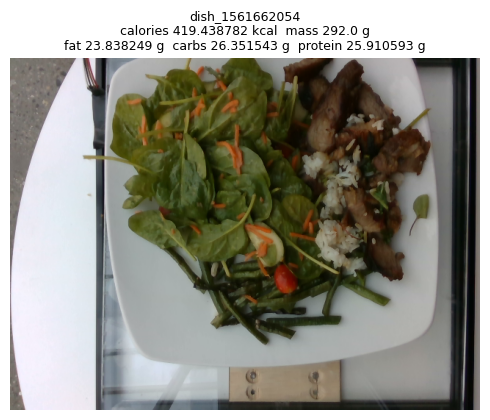

In [ ]:
#sample image
import matplotlib.pyplot as plt

row = train_df.iloc[0]
img = Image.open(os.path.join(IMG_ROOT, row['dish_id'], 'rgb.png')).convert('RGB')

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img)
ax.axis('off')
ax.set_title(
    f"{row['dish_id']}\n"
    f"calories {row['calories']} kcal  mass {row['mass']} g\n"
    f"fat {row['fat']} g  carbs {row['carbs']} g  protein {row['protein']} g",
    fontsize=9)
plt.tight_layout()
plt.savefig('/content/n5k/sample_dish.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
#save stuff
!mkdir -p /content/drive/MyDrive/aps360_project/processed
train_df.to_csv('/content/drive/MyDrive/aps360_project/processed/train.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/aps360_project/processed/val.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/aps360_project/processed/test.csv', index=False)
!cp /content/n5k/target_mean.npy /content/n5k/target_std.npy /content/n5k/target_stats.csv /content/n5k/sample_dish.png /content/drive/MyDrive/aps360_project/processed/

## Baseline Model

In [ ]:
#mean predictor baseline
train_means = train_df[targets].mean()  # original units not z-scored

pred = np.tile(train_means.values, (len(val_df), 1))
true = val_df[targets].values

mae  = np.abs(pred - true).mean(axis=0)
rmse = np.sqrt(((pred - true) ** 2).mean(axis=0))

baseline_results = pd.DataFrame({'MAE': mae, 'RMSE': rmse}, index=targets)
print(baseline_results)
baseline_results.to_csv('/content/n5k/baseline_mean_results.csv')

                 MAE        RMSE
calories  162.366749  195.661129
mass      118.482206  140.914264
protein    14.286528   17.018403
carbs      12.261349   15.976854
fat         9.844175   12.480151


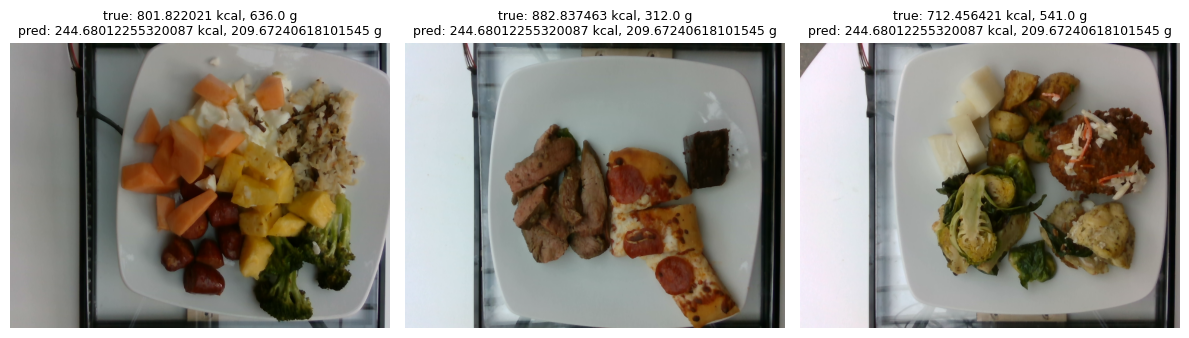

In [ ]:
# dishes where the mean predictor is worst
err_norm = np.abs(pred - true) / train_df[targets].std().values
val_df_err = val_df.copy()
val_df_err['total_err'] = err_norm.sum(axis=1)

worst = val_df_err.nlargest(3, 'total_err')

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
for ax, (_, row) in zip(axes, worst.iterrows()):
    img = Image.open(os.path.join(IMG_ROOT, row['dish_id'], 'rgb.png')).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f"true: {row['calories']} kcal, {row['mass']} g\n"
        f"pred: {train_means['calories']} kcal, {train_means['mass']} g",
        fontsize=9)
plt.tight_layout()
plt.savefig('/content/n5k/baseline_failures.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
!cp /content/n5k/baseline_mean_results.csv /content/n5k/baseline_failures.png /content/drive/MyDrive/aps360_project/processed/

## Primary Model

In [ ]:
#model
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

class NutritionRegressor(nn.Module):
    def __init__(self, name="resnet50_multitask", hidden_size=512, dropout=0.3):
        super(NutritionRegressor, self).__init__()
        self.name = name
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.fc1 = nn.Linear(2048, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(hidden_size, 1) for _ in range(5)])

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        out = torch.cat([head(x) for head in self.heads], dim=1)
        return out

use_cuda = torch.cuda.is_available()
model = NutritionRegressor()
model = model.cuda() if use_cuda else model
num_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {num_params:,}')

total parameters: 24,559,685


In [ ]:
# training
import time
import os

CKPT_DIR = '/content/drive/MyDrive/aps360_project/checkpoints_resnet50'
os.makedirs(CKPT_DIR, exist_ok=True)

def get_model_name(name, batch_size, learning_rate, epoch):
    return f"model_{name}_bs{batch_size}_lr{learning_rate}_epoch{epoch}"

def evaluate(model, loader, criterion):
    # returns avg loss (z-scored) and mae per target
    model.eval()
    total_loss, total_err, n = 0.0, torch.zeros(5), 0
    t_mean, t_std = torch.tensor(target_mean), torch.tensor(target_std)
    if use_cuda:
        t_mean, t_std = t_mean.cuda(), t_std.cuda()
    with torch.no_grad():
        for imgs, labels in loader:
            if use_cuda:
                imgs, labels = imgs.cuda(), labels.cuda()
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            # invert z-score so mae is in kcal / grams
            err = ((out * t_std + t_mean) - (labels * t_std + t_mean)).abs().sum(dim=0)
            total_err += err.cpu()
            n += imgs.size(0)
    return total_loss / n, (total_err / n).numpy()

def train_net(model, train_loader, val_loader, batch_size=64,
              learning_rate=1e-4, num_epochs=15, freeze_epochs=3):
    # huber loss per target
    criterion = nn.SmoothL1Loss()
    tm, ts = torch.tensor(target_mean), torch.tensor(target_std)
    if use_cuda:
        tm, ts = tm.cuda(), ts.cuda()

    for param in model.features.parameters():
        param.requires_grad = False
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

    train_loss = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)
    val_mae = np.zeros((num_epochs, 5))
    train_mae = np.zeros((num_epochs, 5))

    start_time = time.time()
    for epoch in range(num_epochs):
        if epoch == freeze_epochs:
            for param in model.features.parameters():
                param.requires_grad = True
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
            print('backbone unfrozen')

        model.train()
        total_train_loss, n = 0.0, 0
        total_train_err = torch.zeros(5)
        for imgs, labels in train_loader:
            if use_cuda:
                imgs, labels = imgs.cuda(), labels.cuda()
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * imgs.size(0)
            with torch.no_grad():
                total_train_err += ((out * ts + tm) - (labels * ts + tm)).abs().sum(dim=0).cpu()
            n += imgs.size(0)

        train_loss[epoch] = total_train_loss / n
        train_mae[epoch] = (total_train_err / n).numpy()
        val_loss[epoch], val_mae[epoch] = evaluate(model, val_loader, criterion)

        print(f"epoch {epoch+1}: train loss {train_loss[epoch]:.4f} ; "
              f"val loss {val_loss[epoch]:.4f} ; "
              f"val calorie mae {val_mae[epoch][0]:.1f} kcal ; "
              f"val mass mae {val_mae[epoch][1]:.1f} g")

        model_path = get_model_name(model.name, batch_size, learning_rate, epoch)
        torch.save(model.state_dict(), f'{CKPT_DIR}/{model_path}')
        np.savetxt(f'{CKPT_DIR}/train_loss.csv', train_loss[:epoch+1])
        np.savetxt(f'{CKPT_DIR}/val_loss.csv', val_loss[:epoch+1])
        np.savetxt(f'{CKPT_DIR}/train_mae.csv', train_mae[:epoch+1])
        np.savetxt(f'{CKPT_DIR}/val_mae.csv', val_mae[:epoch+1])

    elapsed = time.time() - start_time
    print(f"total time elapsed: {elapsed:.2f} seconds")

    np.savetxt(f'{CKPT_DIR}/{model_path}_train_loss.csv', train_loss)
    np.savetxt(f'{CKPT_DIR}/{model_path}_val_loss.csv', val_loss)
    np.savetxt(f'{CKPT_DIR}/{model_path}_train_mae.csv', train_mae)
    np.savetxt(f'{CKPT_DIR}/{model_path}_val_mae.csv', val_mae)
    return train_loss, val_loss, val_mae


In [ ]:
train_loss, val_loss, val_mae = train_net(model, train_loader, val_loader)

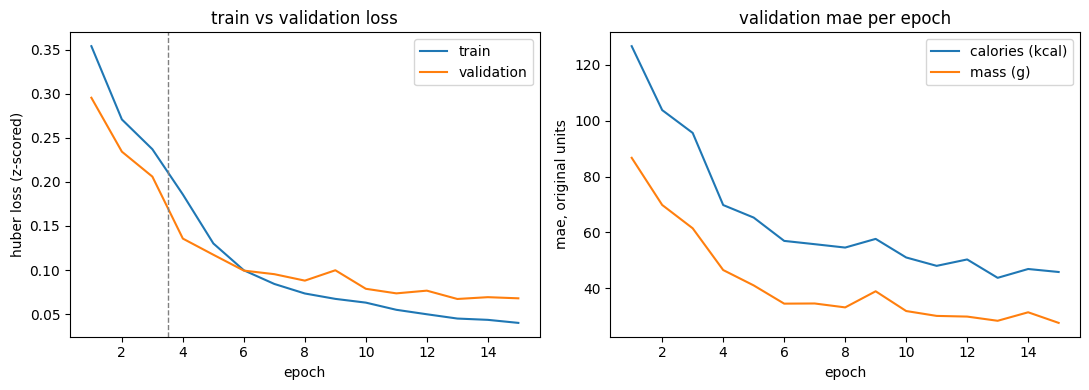

          cnn mae  baseline mae  improvement %
calories    45.81        162.37           71.8
mass        27.59        118.48           76.7
protein      4.60         14.29           67.8
carbs        4.59         12.26           62.6
fat          3.45          9.84           64.9


In [ ]:
# training curves
def plot_training_curve(train_loss, val_loss, val_mae, freeze_epochs=3):
    n = len(train_loss)
    plt.figure(figsize=(11, 4))

    plt.subplot(1, 2, 1)
    plt.title('train vs validation loss')
    plt.plot(range(1, n+1), train_loss, label='train')
    plt.plot(range(1, n+1), val_loss, label='validation')
    plt.axvline(freeze_epochs + 0.5, ls='--', c='gray', lw=1)
    plt.xlabel('epoch')
    plt.ylabel('huber loss (z-scored)')
    plt.legend(loc='best')

    plt.subplot(1, 2, 2)
    plt.title('validation mae per epoch')
    plt.plot(range(1, n+1), val_mae[:, 0], label='calories (kcal)')
    plt.plot(range(1, n+1), val_mae[:, 1], label='mass (g)')
    plt.xlabel('epoch')
    plt.ylabel('mae, original units')
    plt.legend(loc='best')

    plt.tight_layout()
    plt.savefig('/content/n5k/learning_curves.png', dpi=200, bbox_inches='tight')
    plt.show()

plot_training_curve(train_loss, val_loss, val_mae)

final_mae = pd.DataFrame({
    'cnn mae': val_mae[-1],
    'baseline mae': baseline_results['MAE'].values,
}, index=targets).round(2)
final_mae['improvement %'] = (100 * (1 - final_mae['cnn mae'] / final_mae['baseline mae'])).round(1)
print(final_mae)
final_mae.to_csv('/content/n5k/cnn_vs_baseline.csv')

In [ ]:
CKPT_R = '/content/drive/MyDrive/aps360_project/checkpoints_resnet50'
train_loss = np.loadtxt(f'{CKPT_R}/train_loss.csv')
val_loss   = np.loadtxt(f'{CKPT_R}/val_loss.csv')
val_mae    = np.loadtxt(f'{CKPT_R}/val_mae.csv')

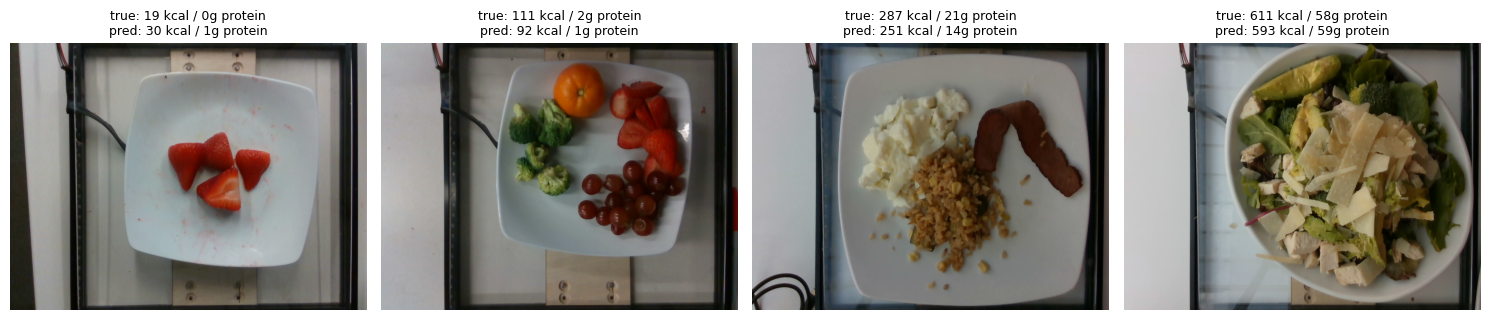

In [ ]:
# qualitative results
model.eval()

val_sorted = val_df.sort_values('calories').reset_index(drop=True)
picks = val_sorted.iloc[[int(len(val_sorted)*q) for q in [0.05, 0.35, 0.65, 0.95]]]

eval_tf = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

t_mean, t_std = torch.tensor(target_mean), torch.tensor(target_std)
if use_cuda:
    t_mean, t_std = t_mean.cuda(), t_std.cuda()

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
for ax, (_, row) in zip(axes, picks.iterrows()):
    img = Image.open(os.path.join(IMG_ROOT, row['dish_id'], 'rgb.png')).convert('RGB')
    x = eval_tf(img).unsqueeze(0)
    if use_cuda:
        x = x.cuda()
    with torch.no_grad():
        p = (model(x) * t_std + t_mean).squeeze().cpu().numpy()
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f"true: {row['calories']:.0f} kcal / {row['protein']:.0f}g protein\n"
        f"pred: {p[0]:.0f} kcal / {p[2]:.0f}g protein", fontsize=9)
plt.tight_layout()
plt.savefig('/content/n5k/cnn_qualitative.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# save to drive
!cp /content/n5k/model_resnet50_multitask* /content/n5k/learning_curves.png /content/n5k/cnn_vs_baseline.csv /content/n5k/cnn_qualitative.png /content/drive/MyDrive/aps360_project/processed/

In [ ]:
# efficientnet variant
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class NutritionRegressorEffNet(nn.Module):
    def __init__(self, name="effnetb0_multitask", hidden_size=512, dropout=0.3):
        super().__init__()
        self.name = name
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(backbone.features, backbone.avgpool)
        self.fc1 = nn.Linear(1280, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(hidden_size, 1) for _ in range(5)])

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return torch.cat([h(x) for h in self.heads], dim=1)

CKPT_DIR = '/content/drive/MyDrive/aps360_project/checkpoints_effnetb0'
os.makedirs(CKPT_DIR, exist_ok=True)

model_eff = NutritionRegressorEffNet()
model_eff = model_eff.cuda() if use_cuda else model_eff
print(f'effnet params: {sum(p.numel() for p in model_eff.parameters()):,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 223MB/s]

effnet params: 4,665,985


In [ ]:
eff_train_loss, eff_val_loss, eff_val_mae = train_net(model_eff, train_loader, val_loader)

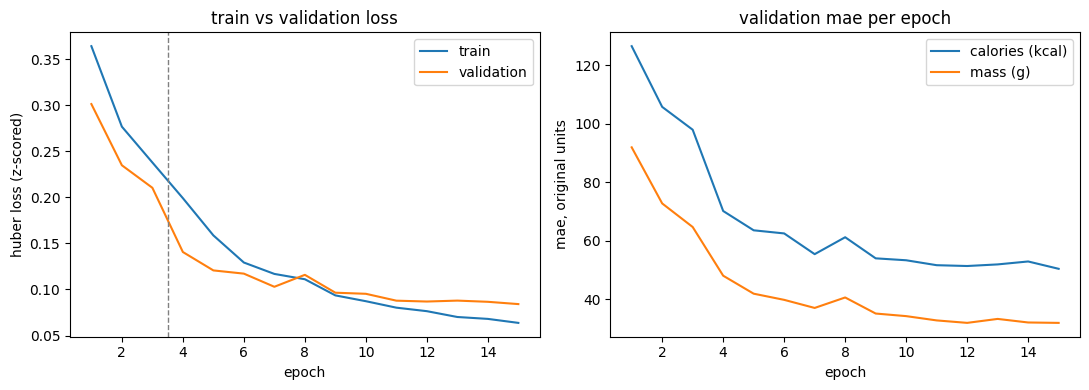

In [ ]:
plot_training_curve(eff_train_loss, eff_val_loss, eff_val_mae)

In [ ]:
# kNN baseline (second baseline)
from sklearn.neighbors import NearestNeighbors

feat_backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
feat_backbone = nn.Sequential(*list(feat_backbone.children())[:-1]).eval()
if use_cuda: feat_backbone = feat_backbone.cuda()

def extract_features(df):
    ds = Nutrition5kDataset(df, IMG_ROOT, target_mean, target_std, train=False)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)
    feats = []
    with torch.no_grad():
        for imgs, _ in loader:
            if use_cuda: imgs = imgs.cuda()
            f = feat_backbone(imgs).view(imgs.size(0), -1)
            feats.append(f.cpu().numpy())
    return np.concatenate(feats)

train_feats = extract_features(train_df)
val_feats   = extract_features(val_df)

K = 5
nn_index = NearestNeighbors(n_neighbors=K).fit(train_feats)
_, idx = nn_index.kneighbors(val_feats)
knn_pred = train_df[targets].values[idx].mean(axis=1)
knn_true = val_df[targets].values

knn_results = pd.DataFrame({
    'MAE':  np.abs(knn_pred - knn_true).mean(axis=0),
    'RMSE': np.sqrt(((knn_pred - knn_true) ** 2).mean(axis=0)),
}, index=targets)
print(knn_results.round(2))
knn_results.to_csv('/content/drive/MyDrive/aps360_project/processed/baseline_knn_results.csv')

            MAE    RMSE
calories  80.86  113.16
mass      56.27   74.24
protein    7.02   10.01
carbs      7.48   10.95
fat        5.17    7.61


In [ ]:
def load_best(model_obj, ckpt_dir, batch_size=64, learning_rate=1e-4):
    vl = np.loadtxt(f'{ckpt_dir}/val_loss.csv')
    best = int(np.argmin(vl))
    path = f'{ckpt_dir}/' + get_model_name(model_obj.name, batch_size, learning_rate, best)
    model_obj.load_state_dict(torch.load(path, map_location='cuda' if use_cuda else 'cpu'))
    model_obj.eval()
    print(f'{model_obj.name}: best epoch {best+1}, val loss {vl[best]:.4f}')
    return model_obj

model     = load_best(model,     '/content/drive/MyDrive/aps360_project/checkpoints_resnet50')
model_eff = load_best(model_eff, '/content/drive/MyDrive/aps360_project/checkpoints_effnetb0')

resnet50_multitask: best epoch 13, val loss 0.0672
effnetb0_multitask: best epoch 15, val loss 0.0841


In [ ]:
# test set eval
criterion = nn.SmoothL1Loss()

_, test_mae_resnet = evaluate(model,     test_loader, criterion)
_, test_mae_effnet = evaluate(model_eff, test_loader, criterion)

mean_pred_test = np.tile(train_df[targets].mean().values, (len(test_df), 1))
test_true = test_df[targets].values
mean_mae_test = np.abs(mean_pred_test - test_true).mean(axis=0)

test_feats = extract_features(test_df)
_, tidx = nn_index.kneighbors(test_feats)
knn_mae_test = np.abs(train_df[targets].values[tidx].mean(axis=1) - test_true).mean(axis=0)

final_table = pd.DataFrame({
    'mean predictor': mean_mae_test,
    'kNN (k=5)':      knn_mae_test,
    'ResNet-50':      test_mae_resnet,
    'EfficientNet-B0':test_mae_effnet,
}, index=targets).round(2)
final_table_pct = (100 * final_table.div(train_df[targets].mean().values, axis=0)).round(1)
print('MAE, test split, n =', len(test_df)); print(final_table)
print('\nMAE as % of target mean'); print(final_table_pct)
final_table.to_csv('/content/drive/MyDrive/aps360_project/processed/final_test_table.csv')
final_table_pct.to_csv('/content/drive/MyDrive/aps360_project/processed/final_test_table_pct.csv')

MAE, test split, n = 496
          mean predictor  kNN (k=5)  ResNet-50  EfficientNet-B0
calories          160.46      92.13      56.59        58.619999
mass              113.53      60.76      34.75        36.820000
protein            14.27       8.31       5.70         5.830000
carbs              13.21       8.66       6.06         5.930000
fat                10.27       6.47       4.19         4.510000

MAE as % of target mean
          mean predictor  kNN (k=5)  ResNet-50  EfficientNet-B0
calories            65.6       37.7       23.1             24.0
mass                54.1       29.0       16.6             17.6
protein             82.3       47.9       32.9             33.6
carbs               71.5       46.9       32.8             32.1
fat                 83.3       52.5       34.0             36.6


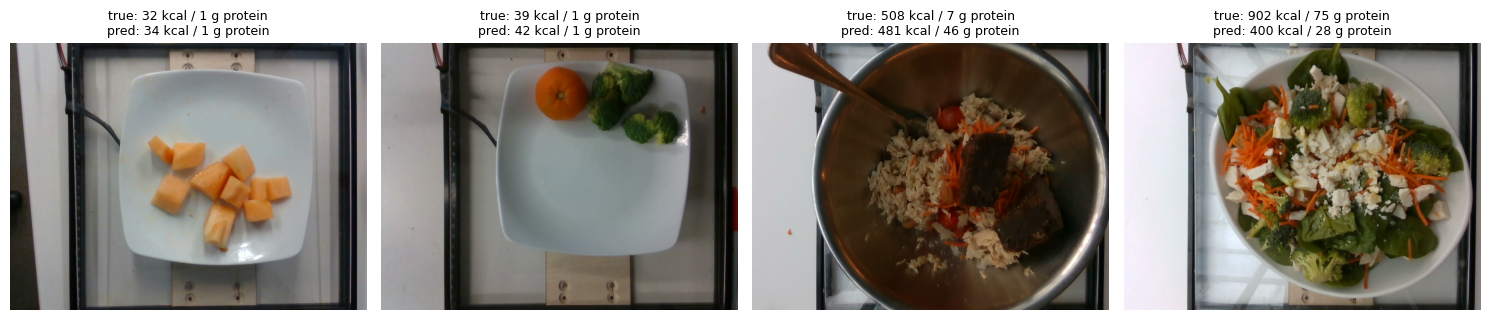

In [ ]:
# qualitative results
t_mean_t = torch.tensor(target_mean); t_std_t = torch.tensor(target_std)
if use_cuda: t_mean_t, t_std_t = t_mean_t.cuda(), t_std_t.cuda()
test_preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        if use_cuda: imgs = imgs.cuda()
        p = model(imgs) * t_mean_t.new_tensor(target_std) + t_mean_t.new_tensor(target_mean)
        test_preds.append(p.cpu().numpy())
test_preds = np.concatenate(test_preds)

err_norm = np.abs(test_preds - test_df[targets].values) / train_df[targets].std().values
order = err_norm.sum(axis=1).argsort()
picks_idx = list(order[:2]) + list(order[-2:])   # 2 best, 2 worst

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
for ax, i in zip(axes, picks_idx):
    row = test_df.iloc[i]
    img = Image.open(os.path.join(IMG_ROOT, row['dish_id'], 'rgb.png')).convert('RGB')
    ax.imshow(img); ax.axis('off')
    ax.set_title(
        f"true: {row['calories']:.0f} kcal / {row['protein']:.0f} g protein\n"
        f"pred: {test_preds[i][0]:.0f} kcal / {test_preds[i][2]:.0f} g protein", fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/aps360_project/processed/test_qualitative.png',
            dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# self collected photo eval
CAF_DIR = '/content/drive/MyDrive/aps360_project/caf'
caf = pd.read_csv(f'{CAF_DIR}/labels.csv')
caf_targets = ['calories','protein','carbs','fat']
caf_idx = [targets.index(t) for t in caf_targets]

eval_tf = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
t_mean_t = torch.tensor(target_mean); t_std_t = torch.tensor(target_std)
if use_cuda: t_mean_t, t_std_t = t_mean_t.cuda(), t_std_t.cuda()

def predict_folder(m):
    preds = []
    with torch.no_grad():
        for _, r in caf.iterrows():
            p = f"{CAF_DIR}/img/{r['item_id']}.jpg"
            if not os.path.isfile(p): p = p.replace('.jpg', '.png')
            x = eval_tf(Image.open(p).convert('RGB')).unsqueeze(0)
            if use_cuda: x = x.cuda()
            preds.append((m(x) * t_std_t + t_mean_t).squeeze().cpu().numpy())
    return np.array(preds)

caf_true = caf[caf_targets].values
caf_table = pd.DataFrame({
    'ResNet-50':       np.abs(predict_folder(model)[:, caf_idx]     - caf_true).mean(axis=0),
    'EfficientNet-B0': np.abs(predict_folder(model_eff)[:, caf_idx] - caf_true).mean(axis=0),
}, index=caf_targets).round(2)
print('MAE, self-collected set, n =', len(caf)); print(caf_table)
caf_table.to_csv(f'{CAF_DIR}/cafeteria_results.csv')

MAE, self-collected set, n = 10
          ResNet-50  EfficientNet-B0
calories     154.61           242.54
protein       13.27            29.28
carbs         24.03            26.44
fat            6.40             3.90


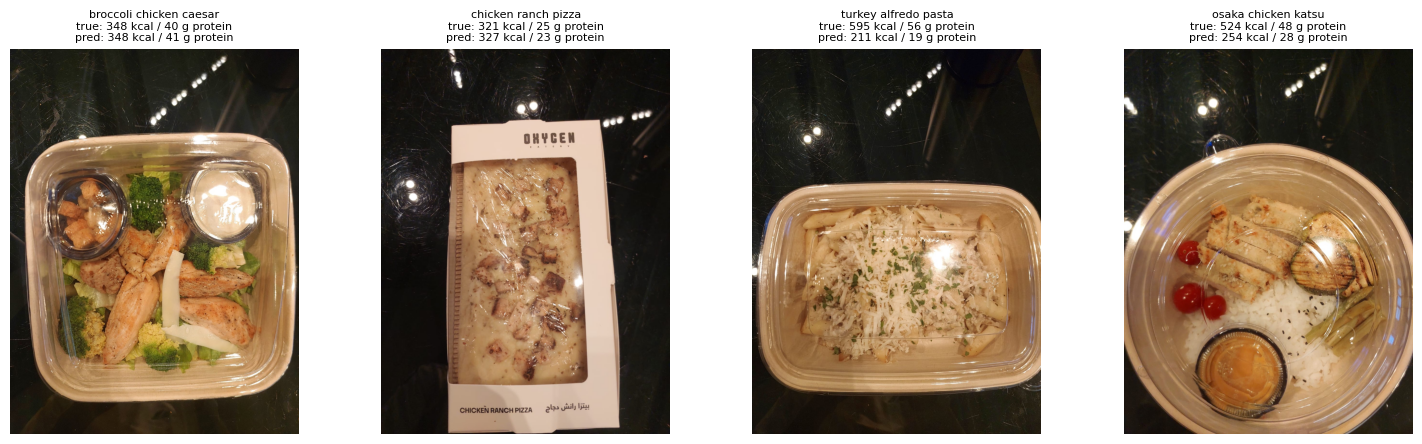

In [ ]:
# qualitative results of self-collected set
caf_preds = predict_folder(model)
caf_pred4 = caf_preds[:, caf_idx]
caf_err = (np.abs(caf_pred4 - caf_true) / train_df[caf_targets].std().values).sum(axis=1)
show = list(caf_err.argsort()[:2]) + list(caf_err.argsort()[-2:])

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
for ax, i in zip(axes, show):
    r = caf.iloc[i]
    p = f"{CAF_DIR}/img/{r['item_id']}.jpg"
    if not os.path.isfile(p): p = p.replace('.jpg', '.png')
    ax.imshow(Image.open(p).convert('RGB')); ax.axis('off')
    ax.set_title(
        f"{r['item_id'].replace('_',' ')}\n"
        f"true: {r['calories']:.0f} kcal / {r['protein']:.0f} g protein\n"
        f"pred: {caf_preds[i][0]:.0f} kcal / {caf_preds[i][2]:.0f} g protein",
        fontsize=8)
plt.tight_layout()
plt.savefig(f'{CAF_DIR}/cafeteria_qualitative.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# new stats
import numpy as np
import torch

CAL = targets.index('calories')
y_true = test_df[targets].values[:, CAL]

def cnn_preds(m):
    m.eval()
    tm = torch.tensor(target_mean); ts = torch.tensor(target_std)
    if use_cuda: tm, ts = tm.cuda(), ts.cuda()
    out = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            if use_cuda: imgs = imgs.cuda()
            p = m(imgs) * ts + tm
            out.append(p.cpu().numpy())
    return np.concatenate(out)[:, CAL]

preds = {
    'Mean predictor': np.full_like(y_true, train_df[targets].values[:, CAL].mean()),
    'kNN (k=5)': train_df[targets].values[nn_index.kneighbors(extract_features(test_df))[1]].mean(axis=1)[:, CAL],
    'ResNet-50': cnn_preds(model),
    'EfficientNet-B0': cnn_preds(model_eff),
}

ss_tot = ((y_true - y_true.mean()) ** 2).sum()
print(f"{'Model':<18}{'MAE':>8}{'RMSE':>8}{'R2':>8}{'Acc@20%':>10}")
for name, p in preds.items():
    mae = np.abs(p - y_true).mean()
    rmse = np.sqrt(((p - y_true) ** 2).mean())
    r2 = 1 - ((p - y_true) ** 2).sum() / ss_tot
    acc20 = 100 * (np.abs(p - y_true) <= 0.2 * np.maximum(y_true, 1e-9)).mean()
    print(f"{name:<18}{mae:8.1f}{rmse:8.1f}{r2:8.2f}{acc20:9.1f}%")

Model                  MAE    RMSE      R2   Acc@20%
Mean predictor       160.5   198.3   -0.00     18.3%
kNN (k=5)             92.1   129.3    0.57     33.1%
ResNet-50             56.6    82.7    0.83     44.4%
EfficientNet-B0       58.6    85.6    0.81     46.2%
